# A Framework for Leveraging LLMs for Scene Analysis and Cognitive Processing

In [1]:
import os
HOME = os.getcwd()

os.chdir(HOME)
print(HOME)

d:\home\Documents\Github\human_patterns_exploration


In [2]:
from src.utils.sam_utils import download_model_weight, download_model_config

INSTALL = False
if INSTALL:
    download_model_weight("sam2.1_hiera_large.pt")
    download_model_config("sam2.1_hiera_l.yaml")
    !pip install sam2


In [3]:
import os
import pandas as pd
from src.core.FixationTask import FixationTask
from src.core.Participant import Participant
from src.core.ImageData import ImageData
from src.core.Mask import Mask
from src.models.MaskGenerator import SAM2

from src.prompts.gaze_prompts import *

In [4]:
font_color =  "yellow"          
COLOR_CODE_1 = "fixation_scarletred_meddark"
COLOR_CODE_2 = "aluminium"
COLOR_CODE_3 = "yellow"

In [5]:

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")

SAM_CONFIG = os.path.join(".", "configs", "sam2.1", "sam2.1_hiera_l.yaml")
SAM_MODEL =  os.path.join(".", "checkpoints", "sam2.1_hiera_large.pt")

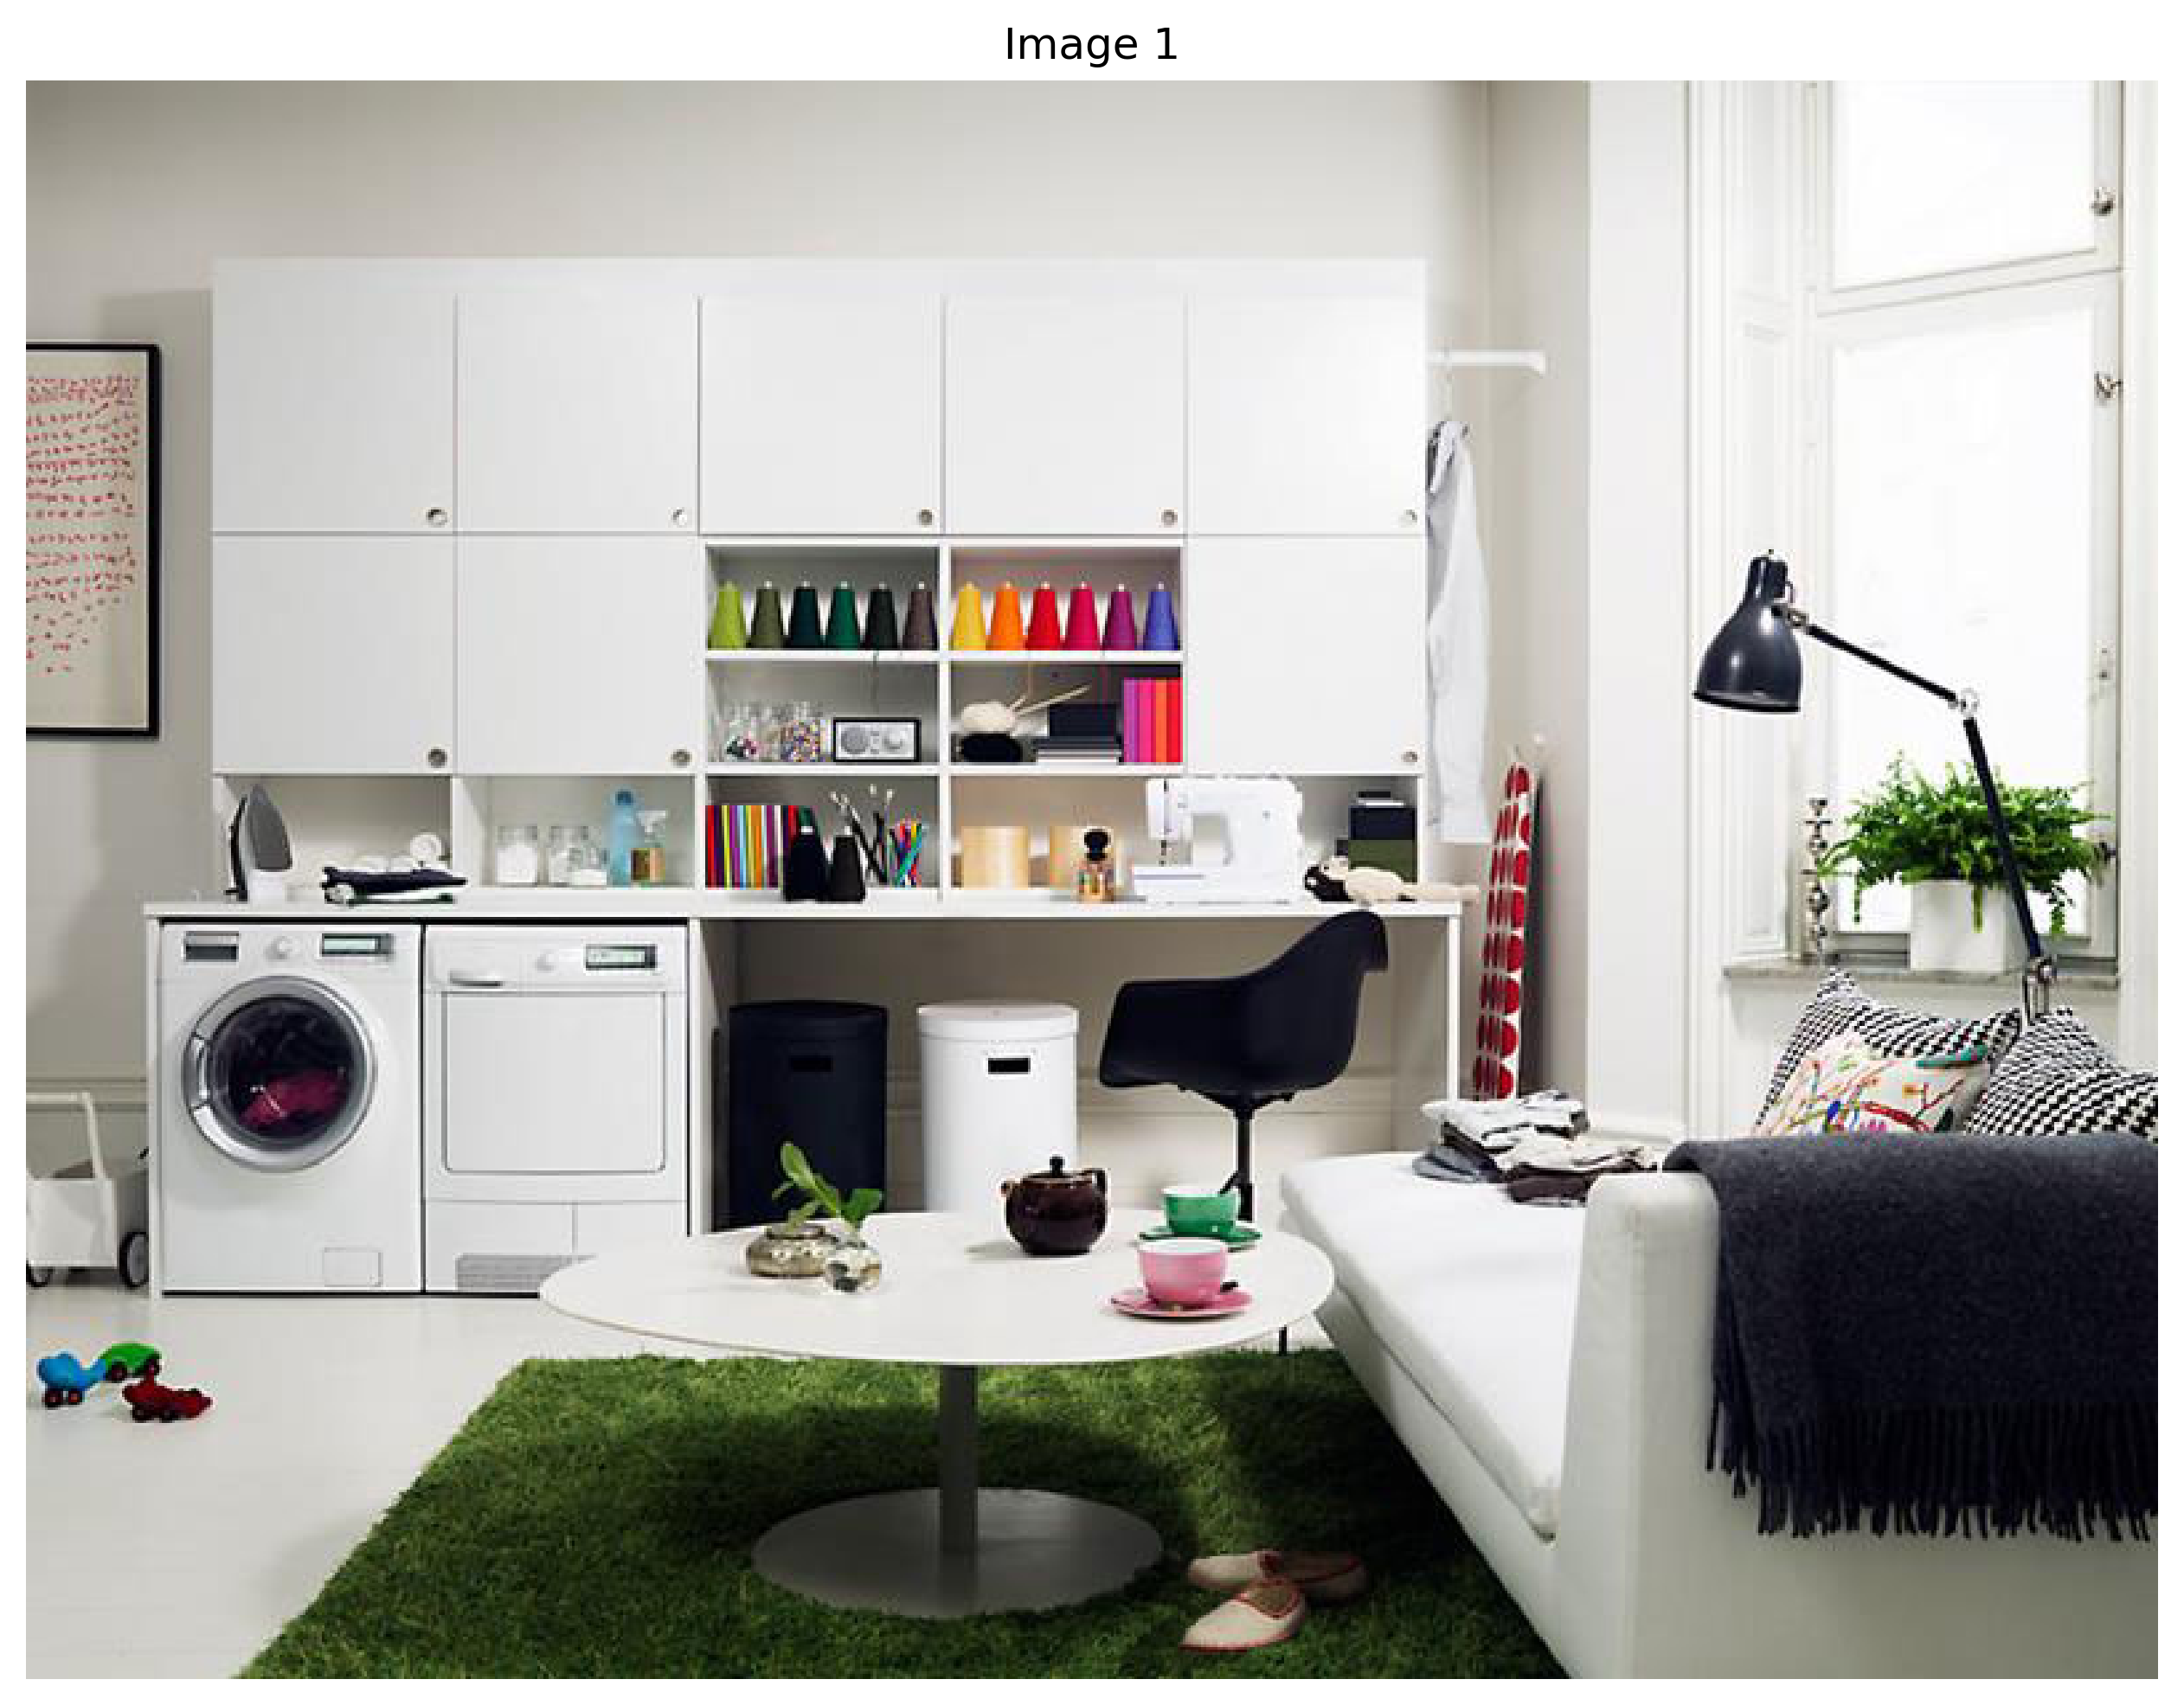

In [6]:
IMG_ID = 1
imgpath = os.path.join(IMAGE_DIR, f"{IMG_ID}exp.jpg")
imageData = ImageData(imgpath)
imageData.show()

## Testing Gaze Points


In [7]:
datapath =  os.path.join("data", "experiments", "XSQ_Expt1_Data_2.csv")
data = pd.read_csv(datapath)

In [8]:
IMG_ID = 1
part_ID = int(data[data.ItemNum == IMG_ID].ParticipantID.unique()[0])
participant =  Participant(part_ID)
print("Participant ID:", part_ID)

imgpath = os.path.join(IMAGE_DIR, f"{IMG_ID}exp.jpg")
print("Image Path:", imgpath)

imageData = ImageData(imgpath, target = [430, 510, 545, 595], img_type = "exp")

CONDITION_ID = 1
GROUP_ID = 1
task = FixationTask(participant, imageData, data, condition = CONDITION_ID, group = GROUP_ID, rows_per_second=1)

Participant ID: 2
Image Path: .\data\images\1exp.jpg
Participant data before center bias removal:  4
Participant data after center bias removal:  3


In [9]:
task_data = task.data.copy()

In [10]:
prompt_0 = task_data.iloc[0]
prompt_1 = task_data.iloc[1]
prompt_2 = task_data.iloc[2]

### Point Gaze Prompt

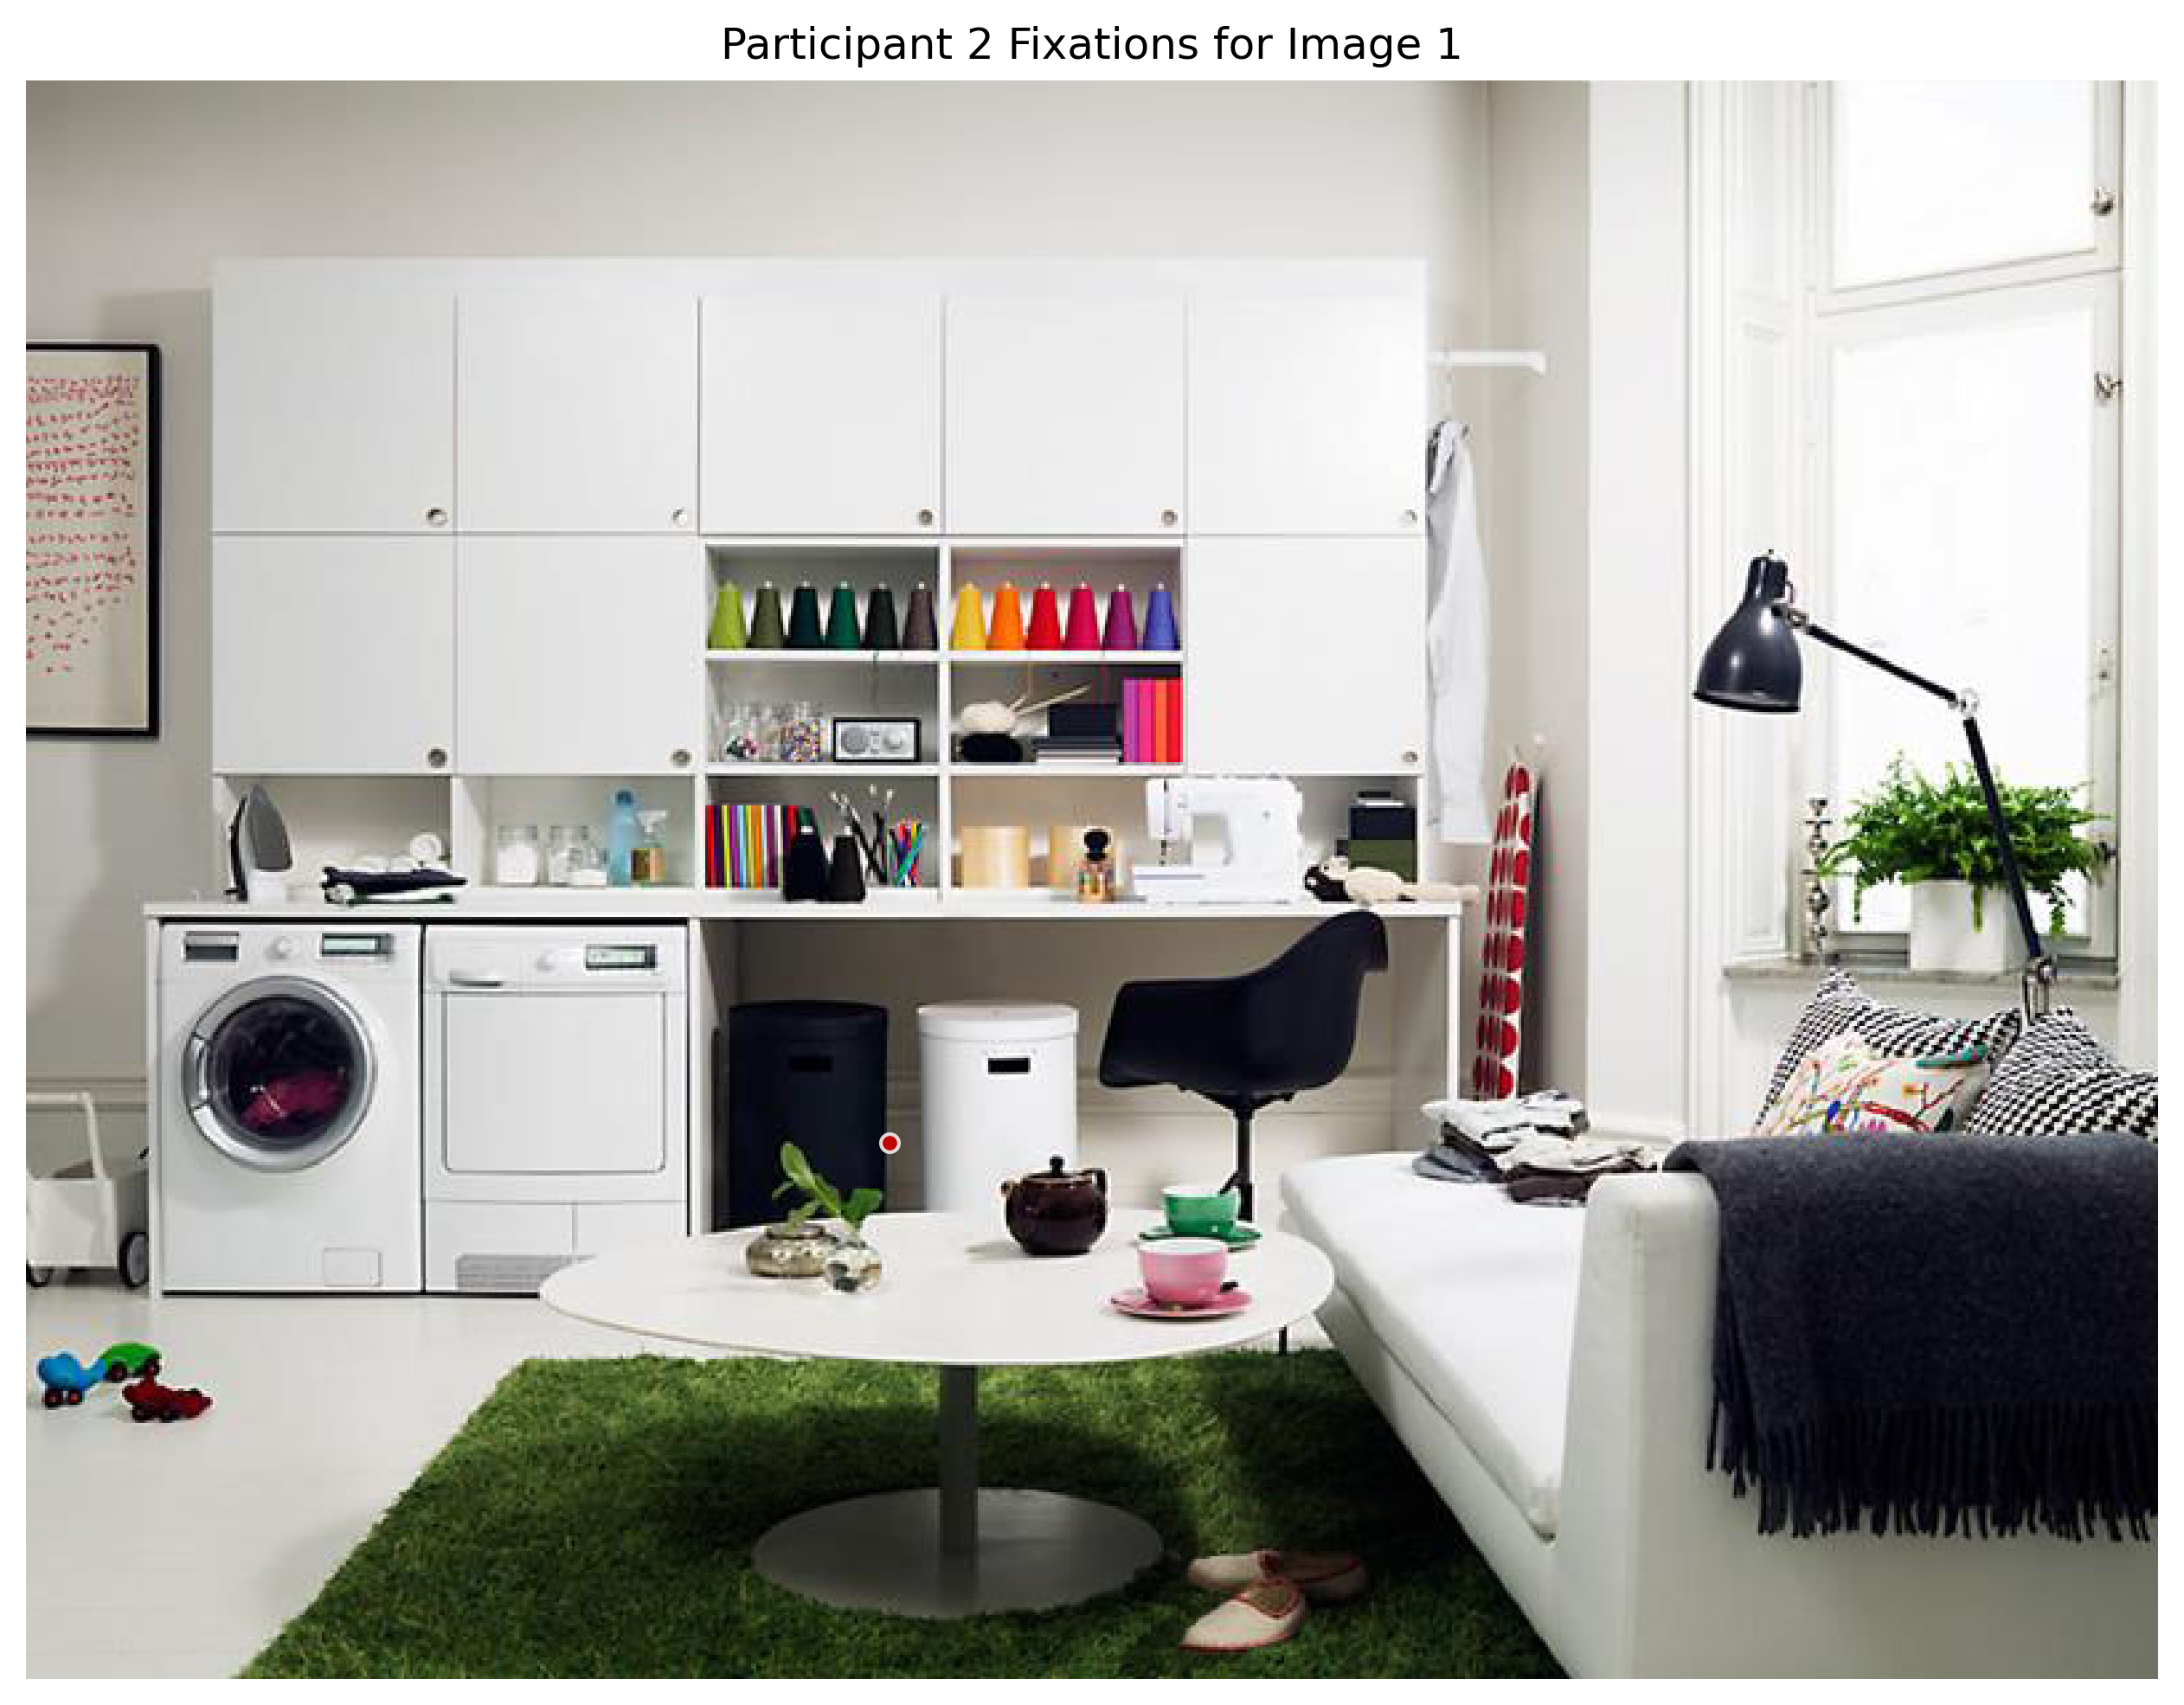

In [11]:
aug_task_data = sample_points_point(prompt_0)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

### Triangle Gaze Prompt

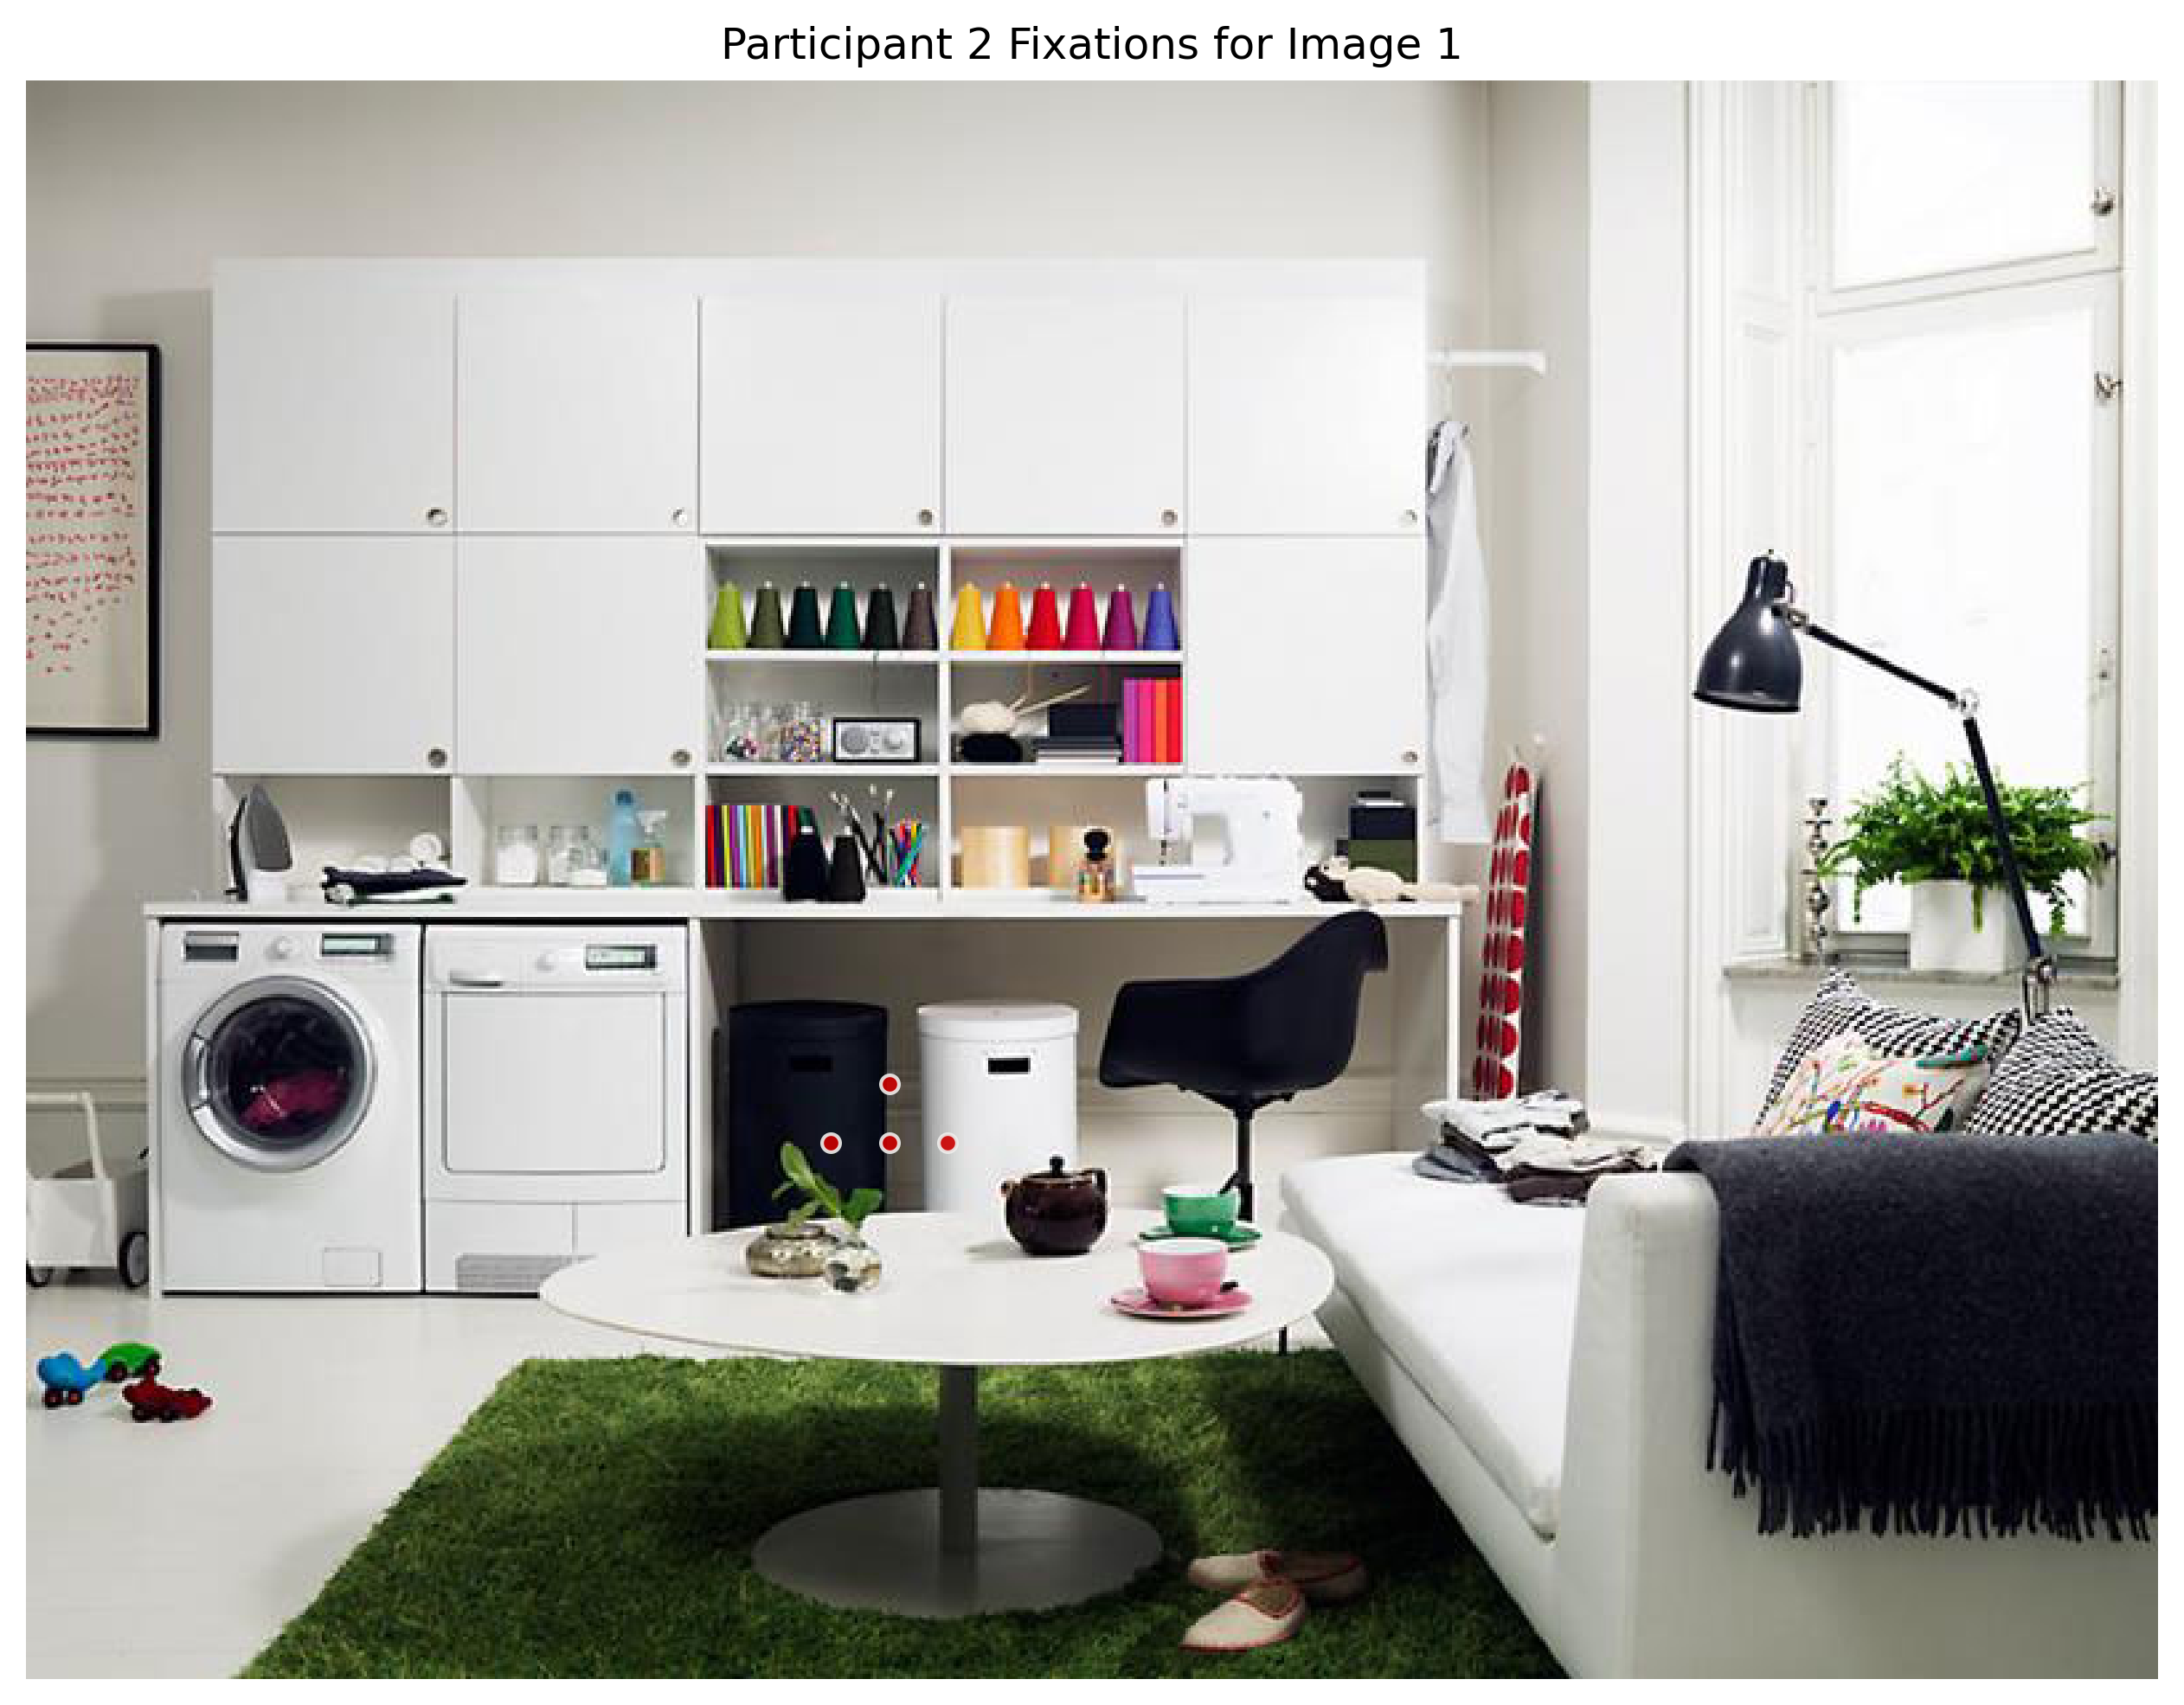

In [12]:
aug_task_data = sample_points_triangle(prompt_0)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

### Cross Gaze Prompt

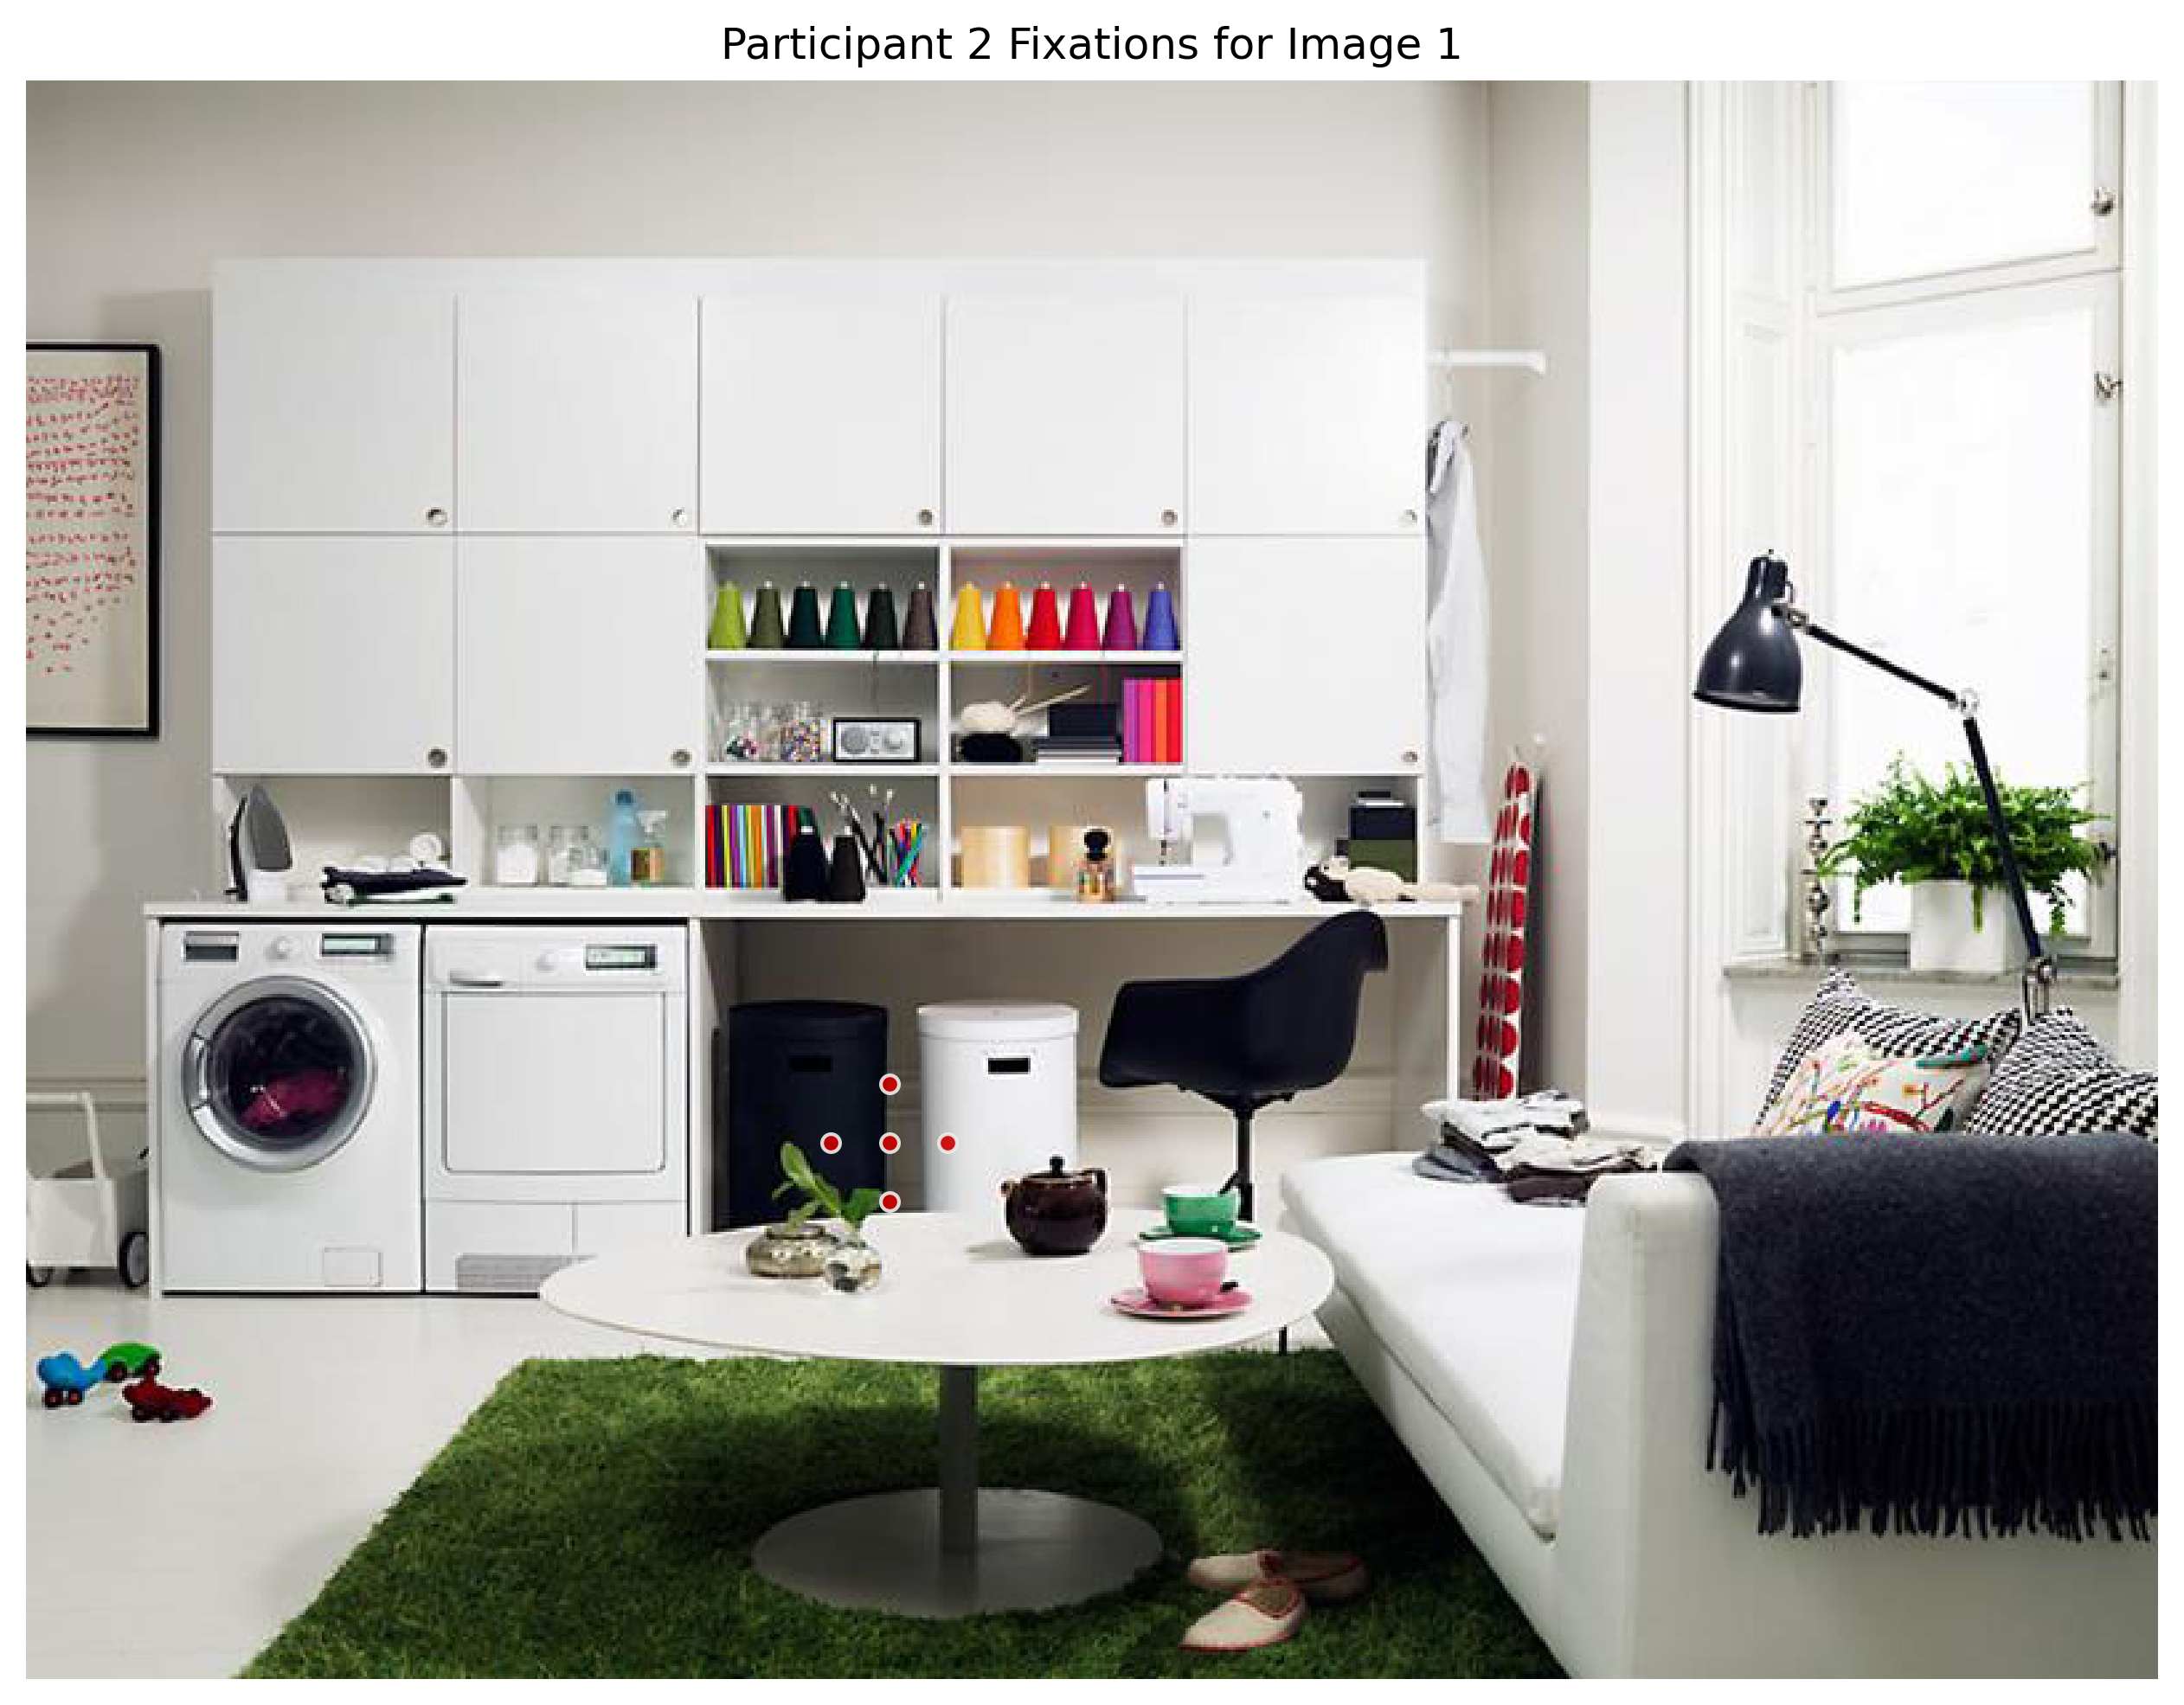

In [13]:
aug_task_data = sample_points_cross(prompt_0)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

### Circle Gaze Prompt

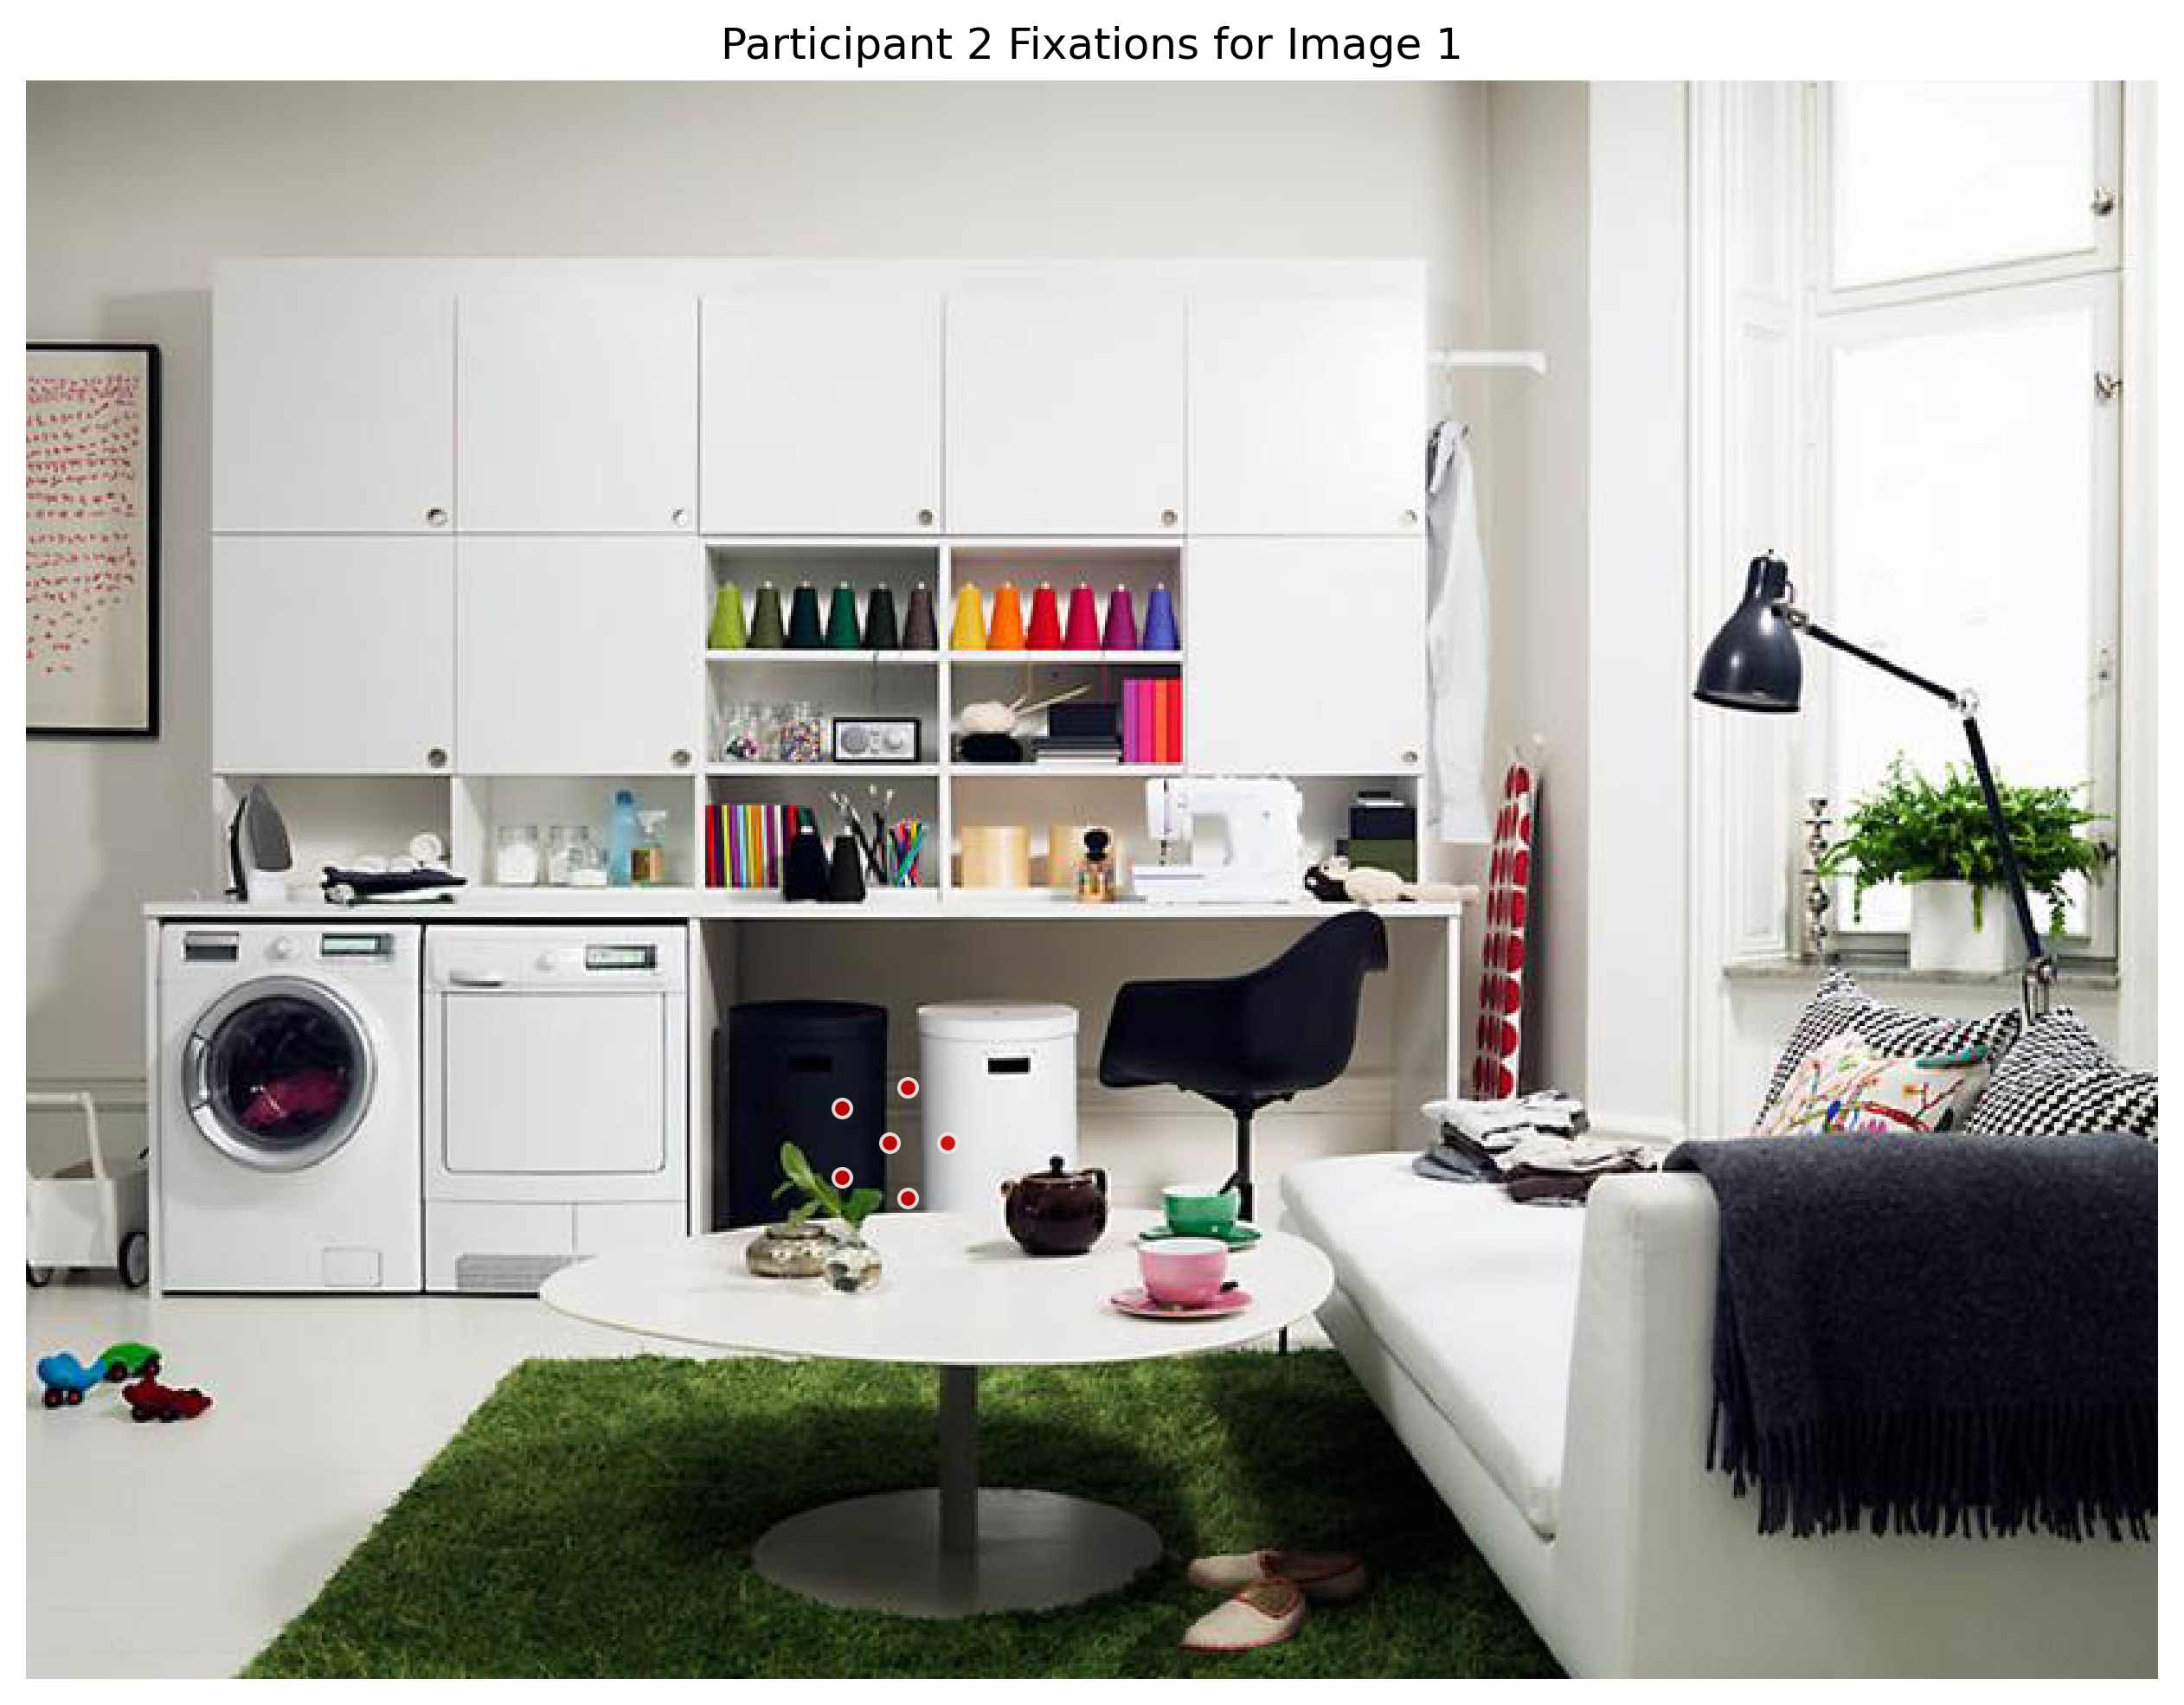

In [14]:
aug_task_data = sample_points_circle(prompt_0, N = 5)
task.draw_fixations( df = aug_task_data, fix_color=COLOR_CODE_1, fix_edge_color=COLOR_CODE_2, alpha=0.9, size = 25 )

## Testing Mask Segmentation and Labeling

Generate the description for this scene

In [10]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance

In [ ]:
# load the experiment data
datapath =  os.path.join("data", "experiments", "XSQ_Expt1_Data_2.csv")
data = pd.read_csv(datapath)

IMG_ID = 1


print("Image Path:", imgpath)


CONDITION_ID = 1
GROUP_ID = 1
EXP_TYPE = "exp"


for img_id in [1]: # substitute this with the range of all images

    print(f"Processing image ID: {IMG_ID}")
    print(f"\tGenerating general scene description...")

    # create an image object
    # todo: get target automatic from Monica's data
    imgpath = os.path.join(IMAGE_DIR, f"{IMG_ID}{EXP_TYPE}.jpg")
    imageData = ImageData(imgpath, target=[430, 510, 545, 595],  img_type = "exp")

    # genetate a scene description
    llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)  # the lower the temperature, the more deterministic is the output
    scene_description =  llm.describe_scene(imageData)
    print(scene_description)

    participants = data[data.ItemNum == IMG_ID].ParticipantID.unique()
    print(participants)


    for part_ID in participants: # just running for 1 participant. Remove this to run for all

        participant =  Participant(part_ID)
        print(f"\nProcessing participant ID = {part_ID}\n")

        task = FixationTask(participant, imageData, data, condition = CONDITION_ID, group = GROUP_ID, rows_per_second=1)

        task_data = task.data.copy()

        # image segmentation object
        mask_gen = SAM2(sam_model_path = SAM_MODEL, sam_model_config = SAM_CONFIG, task = task)

        for fix_indx in task_data.index:

            # select fixation
            fix_prompt = task_data.iloc[fix_indx]

            # segment the image in the region that the participant is fixating
            mask = mask_gen.compute_masks_with_prompt(fix_indx, fix_prompt, output_path=os.path.join(RESULTS_DIR, "Masks"), DEBUG=True, save_mask=True)
            mask.plot()

            # generate label candidates for the mask
            mask_labels = []
            for i in range(0, 10):  # asking the LLM to label the image 10x so we can get a distribution of labels
                mask_label = llm.label_mask(mask, imageData, use_context = True, context = scene_description) 
                mask_labels.append(mask_label)
            mask.labels = mask_labels

            # save the mask object
            mask_gen.save_mask_object(mask, mask.path.replace(".png", ""))



## Generate Scene Descriptions

In [1]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance
from src.core.ImageData import ImageData
import os

In [2]:

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")

SAM_CONFIG = os.path.join(".", "configs", "sam2.1", "sam2.1_hiera_l.yaml")
SAM_MODEL =  os.path.join(".", "checkpoints", "sam2.1_hiera_large.pt")

In [3]:
IMG_ID = 1
IMG_TYPE = "exp"
IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")

image_data = ImageData(path=IMG_PATH, img_type=IMG_TYPE)

llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
scene_description =  llm.describe_scene(image_data=image_data)
scene_description

Scene description completed in 9.21 seconds


'1. **Scene Overview**:  \n   The image depicts a modern, multifunctional living space that combines elements of a laundry area and a cozy sitting area. The room features a light color palette with a mix of functional furniture and decorative items, creating a warm and inviting atmosphere.\n\n2. **Identified Objects**:  \n   - **Washing Machine**: Located on the left side of the image, it has a front-loading door and is white in color.\n   - **Dryer**: Positioned next to the washing machine, also white, with a similar front-loading design.\n   - **Storage Cabinets**: Above the washing machine and dryer, there are white cabinets with multiple doors, providing storage space.\n   - **Desk**: A long, white desk is situated in the center of the image, extending from the washing machine to the right side.\n   - **Chair**: A black chair is placed in front of the desk.\n   - **Desk Items**: Various items on the desk include colored cones, stationery, a sewing machine, and a few decorative obje

In [5]:
IMG_ID = 1
IMG_TYPE = "exp"
IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")

image_data = ImageData(path=IMG_PATH, img_type=IMG_TYPE)

llm = create_llm_instance("ollama", "llava:34b", temperature=0.1)
scene_description =  llm.describe_scene(image_data=image_data)
scene_description

Ollama connection successful. Using model: llava:34b
Scene description completed in 638.79 seconds


"1. **Scene Overview**: The image depicts a modern, multi-purpose room that combines elements of both a living area and a laundry/workspace. The space is well-lit and features clean lines, with various furniture pieces and appliances arranged to create a functional environment for work, leisure, and household chores.\n2. **Identified Objects**: \n   - A white cabinet against the wall on the left side of the room.\n   - On top of this cabinet, there are several items including what appears to be a stack of books or folders, a decorative object resembling an abstract sculpture, and possibly some small appliances or office supplies.\n   - Adjacent to the cabinet, there is a white countertop with various objects on it, including what could be cleaning supplies, stationery, or craft materials. A black lamp with a curved neck stands out among these items.\n   - Below the countertop, a washing machine is installed into the cabinetry, indicating that this room also serves as a laundry area.\n 

## KG Generator

In [1]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance
from src.core.ImageData import ImageData
from src.models.KG import KnowledgeGraph
import os
import pickle

In [2]:
HOME = os.getcwd()
os.chdir(HOME)

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")

SAM_CONFIG = os.path.join(".", "configs", "sam2.1", "sam2.1_hiera_l.yaml")
SAM_MODEL =  os.path.join(".", "checkpoints", "sam2.1_hiera_large.pt")

In [ ]:
IMG_ID = 1
IMG_TYPE = "exp"
IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")

image_data = ImageData(path=IMG_PATH, img_type=IMG_TYPE)

llm_provider = "openai"

# load img scene description
scene_descr_path = os.path.join(RESULTS_DIR, "SceneDescriptions", f"{llm_provider}_results", f"IMG_{IMG_ID}_{IMG_TYPE}_descr.txt")
image_data.load_scene_description(scene_descr_path)

1. **Scene Overview**:  
   The image depicts a modern, multifunctional living space that combines elements of a laundry area and a cozy sitting area. The room features a light color palette with a mix of functional furniture and decorative items, creating a warm and inviting atmosphere.

2. **Identified Objects**:  
   - **Washing Machine**: Located on the left side of the image, it has a front-loading door and is white in color.
   - **Dryer**: Positioned next to the washing machine, also white, with a similar front-loading design.
   - **Storage Cabinets**: Above the washing machine and dryer, there are white cabinets with multiple doors, providing storage space.
   - **Desk**: A long, white desk is situated in the center of the image, extending from the washing machine to the right side.
   - **Chair**: A black chair is placed in front of the desk.
   - **Desk Items**: Various items on the desk include colored cones, stationery, a sewing machine, and a few decorative objects.
   - 

In [4]:
# get all masks related to the image
masks_path_dir = os.path.join(RESULTS_DIR, "Masks", "BestMask")

# list files in directory
masks = []
mask_files = os.listdir(masks_path_dir)
mask_files = [file for file in mask_files if file.endswith('.pkl')]
mask_files = [file for file in mask_files if f"IMG_{IMG_ID}_type_{IMG_TYPE}" in file] # select all the masks of a specific image
for file in mask_files:
    with open(os.path.join(masks_path_dir, file), 'rb') as mask_file:
        mask_data = pickle.load(mask_file)
        mask_data.get_most_frequent_label()
        masks.append(mask_data)

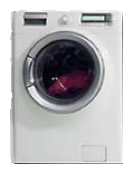

['washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing']
washing
1.0


In [5]:
# checking if everything is okay
masks[5].plot()
print(masks[5].labels)
print(masks[5].most_freq_label)
print(masks[5].most_freq_prob)

In [6]:
# call the KG builder
llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
KG = KnowledgeGraph(llm, image_data)

In [ ]:
# triples = KG.generate_triples( masks )
# triples

In [ ]:
# kg_triples = KG.parse_triples( triples )

In [7]:


KG.load_triples( os.path.join(RESULTS_DIR, "KnowledgeGraph", "triples_final", "IMG_1_exp_triples.txt") );


Successfully loaded 51 triples from .\outputs\KnowledgeGraph\triples_final\IMG_1_exp_triples.txt


Relationship matrix saved to outputs\KnowledgeGraph\knowledge_matrices\IMG_1_exp_knowledge_matrix.png


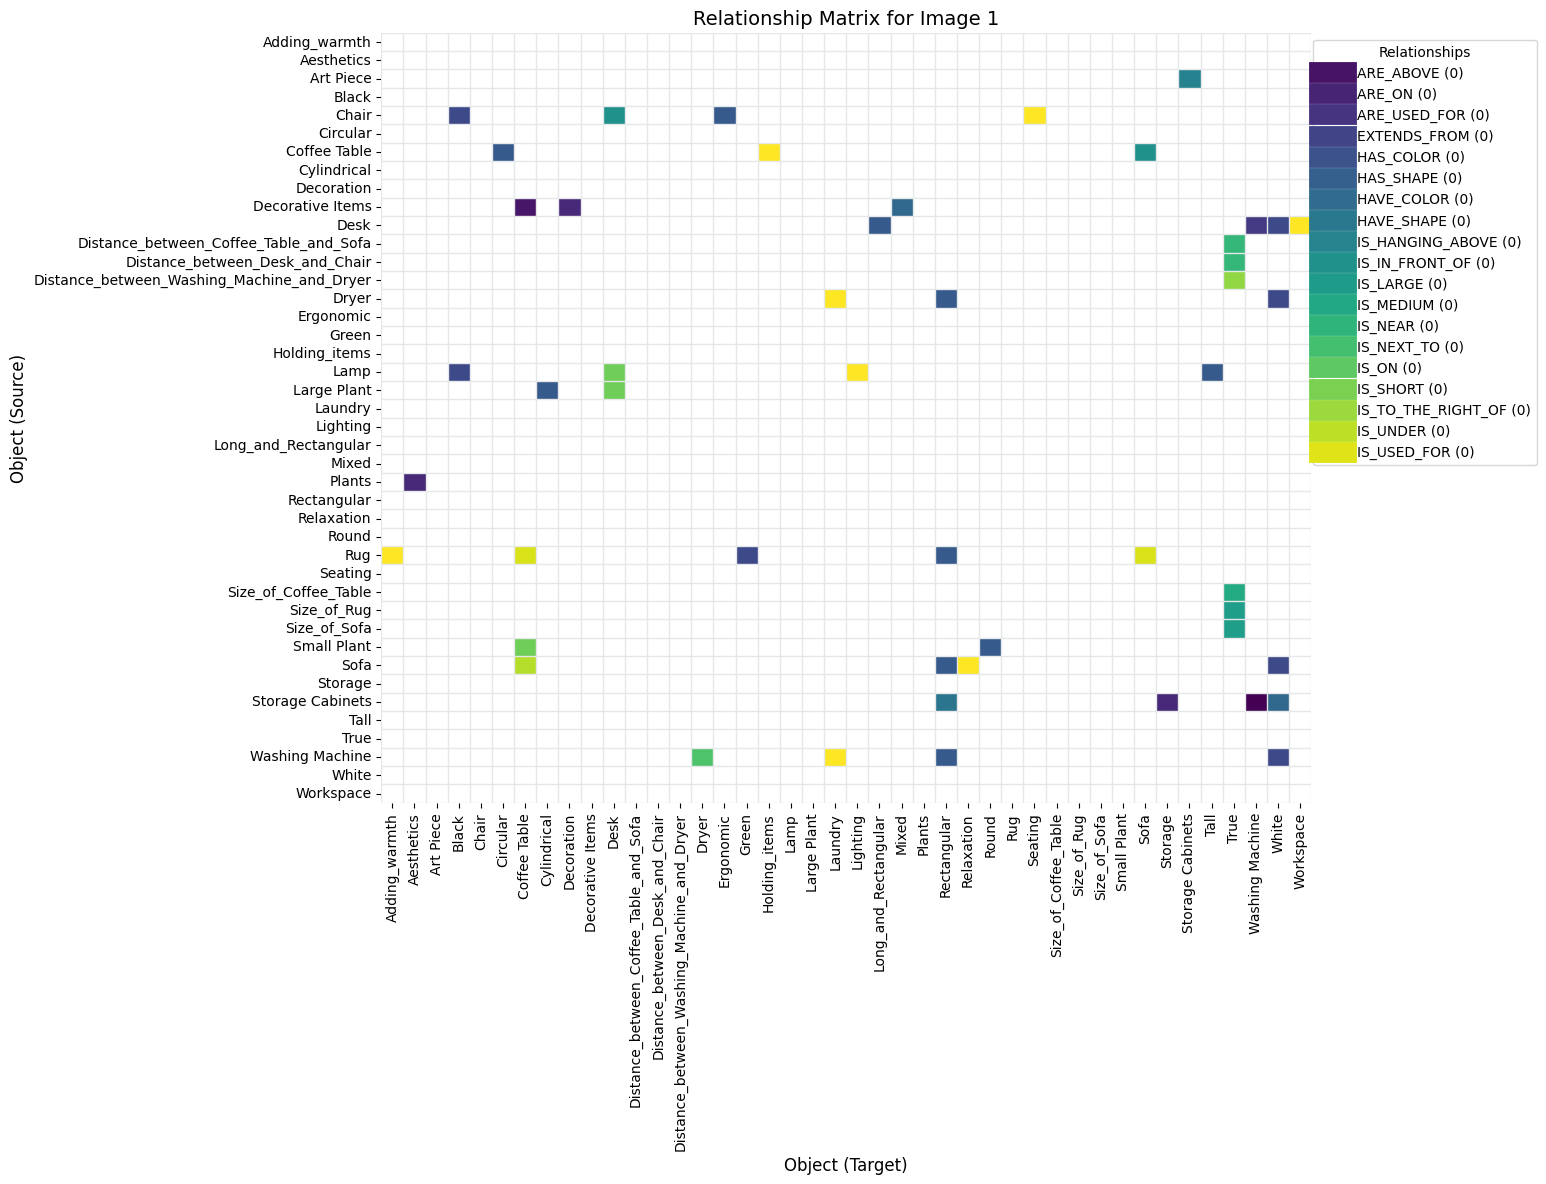

In [8]:
KG.plot_relationship_matrix()

In [9]:
KG.build_graph()

In [10]:
kg_matrix = KG.get_adjacency_matrix( save=True)
kg_matrix

Adjacency matrix saved to outputs\KnowledgeGraph\knowledge_matrices\IMG_1_exp_adjacency_matrix.csv


,Washing Machine,Dryer,Storage Cabinets,Desk,Chair,Coffee Table,Sofa,Rug,Lamp,Small Plant,...,Round,Cylindrical,Tall,Distance_between_Washing_Machine_and_Dryer,True,Distance_between_Desk_and_Chair,Distance_between_Coffee_Table_and_Sofa,Size_of_Coffee_Table,Size_of_Sofa,Size_of_Rug
Washing Machine,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Dryer,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Storage Cabinets,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Desk,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Chair,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Coffee Table,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Sofa,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Rug,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Lamp,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
Small Plant,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


Professional knowledge graph saved to outputs\KnowledgeGraph\1_knowledge_graph_professional.png
PDF version saved to outputs\KnowledgeGraph\1_knowledge_graph_professional.pdf


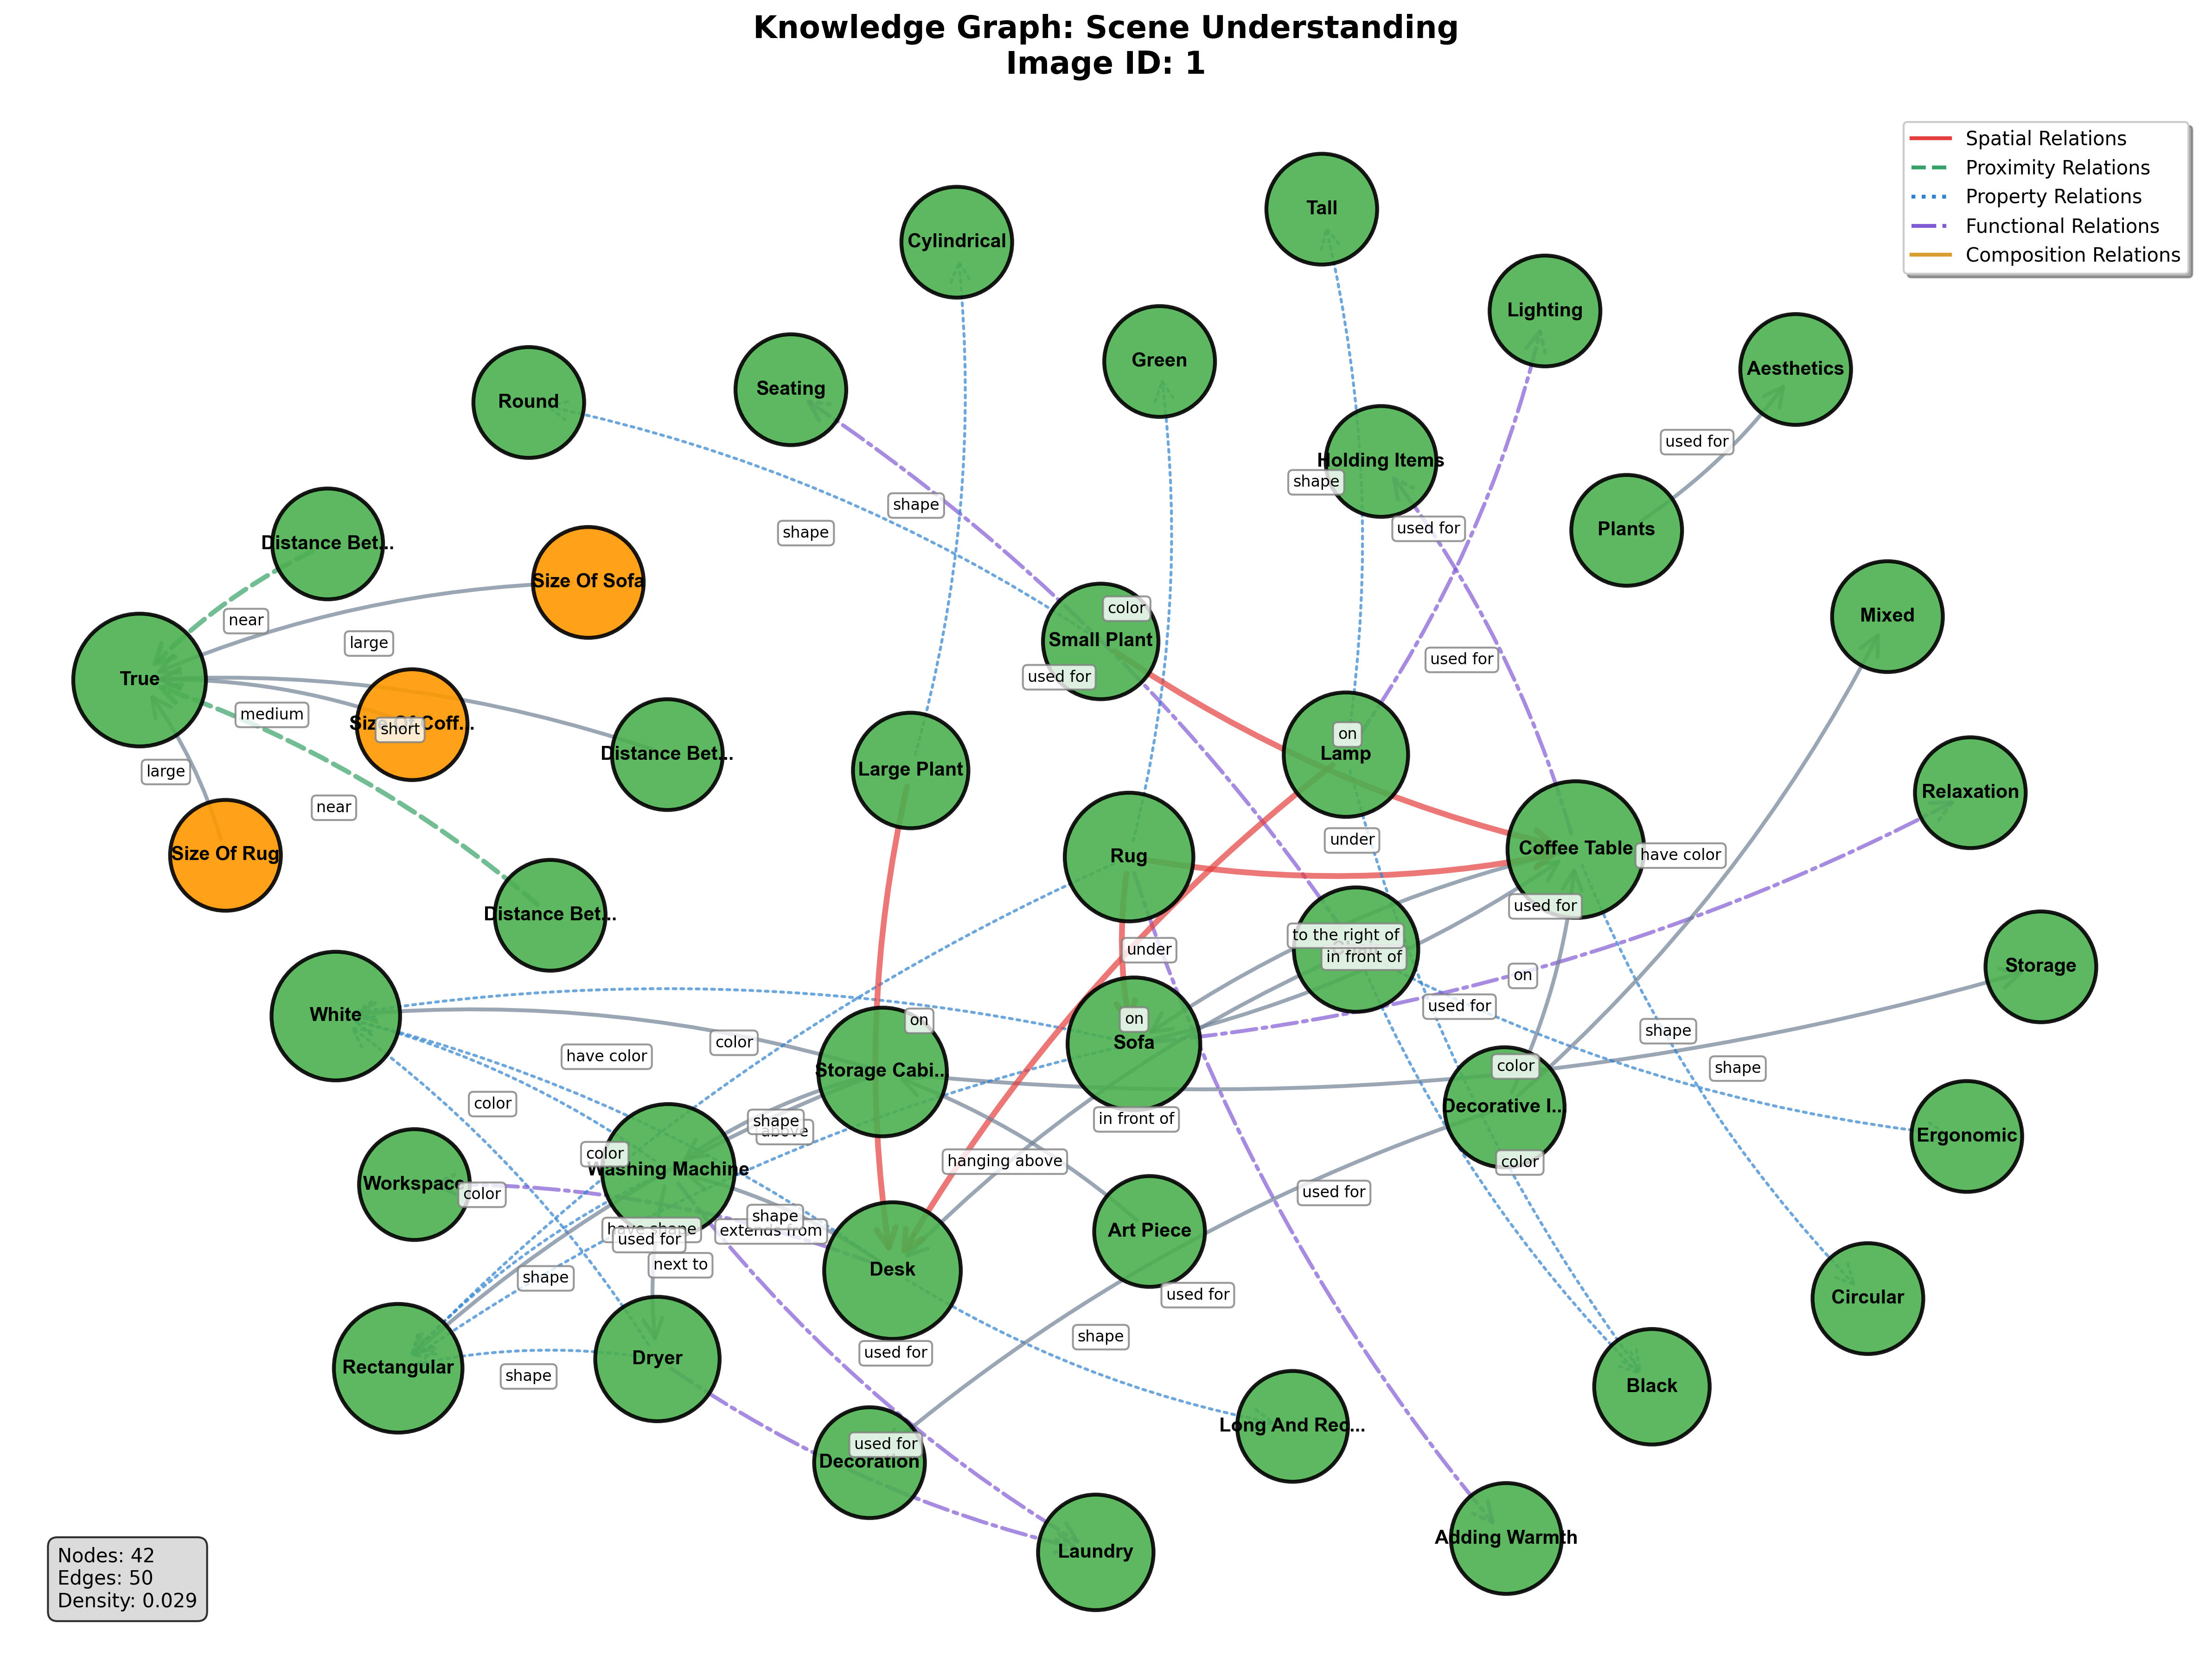

In [12]:

KG.plot_knowledge_graph(layout_algorithm="spring", scale=1.0, k_param = 10.0)